# Massive canonical 数据体检

验证 HTTPS 私有来源、Source receipt、事件覆盖、报价点差、可见延迟和重放视图。Notebook 只读取受管 Dataset ID，不调用 Massive API。

In [1]:
from pathlib import Path
from datetime import datetime
import json, os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'kairos').exists():
    ROOT = ROOT.parent
DATASET_ID = os.environ.get('MASSIVE_EVENT_DATASET', 'options.us.massive.aapl.atm.20260715.https.v1')
print('root:', ROOT)
print('dataset:', DATASET_ID)

root: /path/to/kairos-project
dataset: options.us.massive.aapl.atm.20260715.https.v1


In [2]:
from kairos.market_data import ParquetMarketEventRepository

repository = ParquetMarketEventRepository(ROOT / 'data/canonical/market')
metadata = repository.metadata(DATASET_ID)
display(pd.DataFrame({
    'rows': [metadata['manifest']['rows']],
    'dataset_sha256': [metadata['manifest']['dataset_sha256']],
    'publishable': [metadata['quality']['publishable']],
    'calendar': [metadata['coverage']['calendar']],
}))
display(pd.json_normalize(metadata['quality']['reconciliation']))

,rows,dataset_sha256,publishable,calendar
0,7255,6fef55e29b129e8219c27d349ab437c330cf580a2c20b7...,True,US_SECURITIES


,delivered_event_records,decoded_event_records,canonical_event_records,filtered_outside_request_window,quarantined_records
0,7641,7255,7255,386,0


In [3]:
source = metadata['lineage']['source']
assert source['api_base'] == 'https://api.massiveprivateserver.site', source
receipt_rows = []
for relative in metadata['lineage']['source_receipts']:
    receipt = json.loads((ROOT / 'data' / relative).read_text())
    receipt_rows.append({
        'resource': receipt['resource'], 'scheme': receipt['transport_scheme'],
        'pages': receipt['page_count'], 'records': receipt['record_count'],
        'bytes': receipt['response_bytes'], 'status': receipt['status'],
    })
receipts = pd.DataFrame(receipt_rows)
assert not receipts.empty and receipts['scheme'].eq('https').all()
display(receipts)

,resource,scheme,pages,records,bytes,status
0,/v3/reference/tickers/AAPL,https,1,1,999,complete
1,/v2/aggs/ticker/AAPL/range/1/minute/2026-07-15...,https,1,391,10214,complete
2,/v3/reference/options/contracts,https,4,3588,24883,complete
3,/v3/quotes/O:AAPL260717C00315000,https,1,788,14816,complete
4,/v3/trades/O:AAPL260717C00315000,https,1,167,3390,complete
5,/v3/quotes/O:AAPL260717P00315000,https,1,1130,21299,complete
6,/v3/trades/O:AAPL260717P00315000,https,1,130,2597,complete
7,/v3/quotes/O:AAPL260717C00317500,https,1,780,14625,complete
8,/v3/trades/O:AAPL260717C00317500,https,1,243,4558,complete
9,/v3/quotes/O:AAPL260717P00317500,https,1,993,19065,complete


In [4]:
window = metadata['lineage']['request_window']
start, end = datetime.fromisoformat(window['start']), datetime.fromisoformat(window['end'])
events = list(repository.scan(DATASET_ID, start, end, view='raw-as-received'))
rows = []
for event in events:
    rows.append({
        'instrument_id': event.instrument_id.value, 'type': event.record_type.value,
        'event_time': event.event_time, 'available_time': event.available_time,
        'latency_ms': (event.available_time-event.event_time).total_seconds()*1000,
        **event.payload,
    })
frame = pd.DataFrame(rows)
assert len(frame) == metadata['manifest']['rows']
display(frame.groupby('type').size().rename('rows').to_frame())
display(frame.head())

,rows
type,
bar,5
quote,6016
trade,1234


,instrument_id,type,event_time,available_time,latency_ms,close,high,low,open,period_end,...,bid,bid_exchange,bid_size,conditions,sequence_number,correction,exchange,price,size,trade_id
0,equity:us:AAPL,bar,2026-07-15 13:30:00+00:00,2026-07-15 13:30:00+00:00,0.0,317.55,317.55,317.14,317.38,2026-07-15T13:30:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,option:us:AAPL260717C00317500,quote,2026-07-15 13:30:00.099117+00:00,2026-07-15 13:30:00.099117+00:00,0.0,NaN,NaN,NaN,NaN,NaN,...,2.53,307.0,2,[],1109835.0,NaN,NaN,NaN,NaN,NaN
2,option:us:AAPL260717P00317500,quote,2026-07-15 13:30:00.099132+00:00,2026-07-15 13:30:00.099132+00:00,0.0,NaN,NaN,NaN,NaN,NaN,...,2.63,307.0,2,[],1109836.0,NaN,NaN,NaN,NaN,NaN
3,option:us:AAPL260717P00315000,quote,2026-07-15 13:30:00.103212+00:00,2026-07-15 13:30:00.103212+00:00,0.0,NaN,NaN,NaN,NaN,NaN,...,1.58,307.0,2,[],1109911.0,NaN,NaN,NaN,NaN,NaN
4,option:us:AAPL260717C00317500,quote,2026-07-15 13:30:00.206874+00:00,2026-07-15 13:30:00.206874+00:00,0.0,NaN,NaN,NaN,NaN,NaN,...,2.69,307.0,2,[],1113948.0,NaN,NaN,NaN,NaN,NaN


,bid,ask,spread,relative_spread,latency_ms
count,6016.000000,6016.000000,6016.000000,6016.000000,6016.0
mean,2.812668,3.093679,0.281011,0.093386,0.0
std,1.053651,1.170578,0.369860,0.124045,0.0
min,0.000000,1.400000,0.010000,0.003839,0.0
25%,2.090000,2.280000,0.110000,0.045549,0.0
50%,2.510000,2.620000,0.190000,0.069444,0.0
75%,3.500000,3.900000,0.350000,0.097902,0.0
max,5.400000,6.750000,5.000000,2.000000,0.0


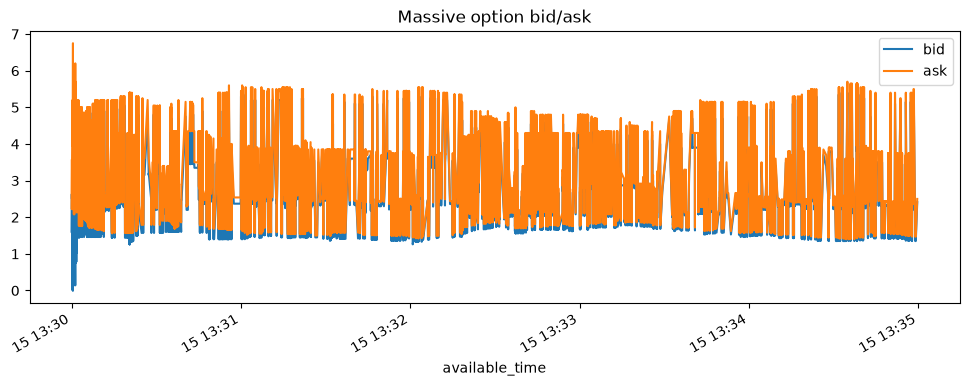

In [5]:
quotes = frame[frame['type'].eq('quote')].copy()
if not quotes.empty:
    quotes['bid'] = pd.to_numeric(quotes['bid'])
    quotes['ask'] = pd.to_numeric(quotes['ask'])
    quotes['mid'] = (quotes['bid'] + quotes['ask']) / 2
    quotes['spread'] = quotes['ask'] - quotes['bid']
    quotes['relative_spread'] = quotes['spread'] / quotes['mid'].where(quotes['mid'].ne(0))
    display(quotes[['bid','ask','spread','relative_spread','latency_ms']].describe())
    quotes.set_index('available_time')[['bid','ask']].plot(figsize=(12,4), title='Massive option bid/ask')
    plt.show()

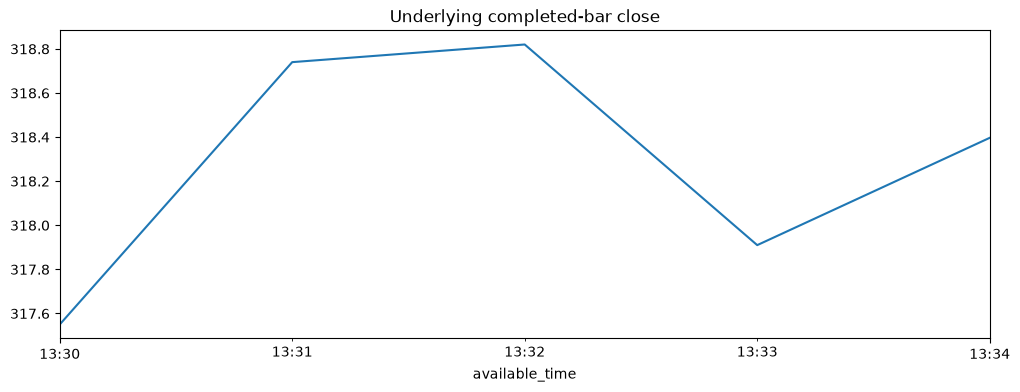

,view,rows
0,raw-as-received,7255
1,corrected-final,7255


In [6]:
bars = frame[frame['type'].eq('bar')].copy()
if not bars.empty:
    bars['close'] = pd.to_numeric(bars['close'])
    bars.set_index('available_time')['close'].plot(figsize=(12,4), title='Underlying completed-bar close')
    plt.show()
raw_count = len(events)
final_count = len(list(repository.scan(DATASET_ID, start, end, view='corrected-final')))
display(pd.DataFrame({'view':['raw-as-received','corrected-final'], 'rows':[raw_count, final_count]}))